# Everyone Watches Women’s Basketball: Attendance and Fan Engagement in

the WNBA

Gabriela Eastwood [](https://orcid.org/0009-0004-7969-198X) ([University of Chicago](https://harris.uchicago.edu/), [Smith College](https://www.smith.edu/), University of Chicago)  
[Benjamin S. Baumer](https://www.smith.edu/people/ben-baumer) [](https://orcid.org/0000-0002-3279-0516) ([Smith College](https://www.smith.edu/))  
[Andrew Zimbalist](https://www.smith.edu/people/andrew-zimbalist) ([Smith College](https://www.smith.edu/), )  
July 12, 2026

We examine how the relationships between attendance and three notions of fan engagement have changed over the history of the WNBA. Previous research suggests that stronger professional sports teams draw higher live game attendance. However, there is ongoing doubt about the extent to which that relationship holds in the WNBA. We improve upon previous research by modeling attendance in the broader context of the league’s growth from 1997-2025, and find that the factors that drive fan demand have evolved as the league has matured. We test whether three leading theories of fan behavior—quality of play, loss aversion, and outcome uncertainty—have become more important drivers of attendance as the league has grown. We use game-level attendance data reported directly by the WNBA as well as team Elo ratings and game-by-game home win probabilities and find that in recent years fans are increasingly likely to attend games in response to quality of play and loss aversion factors. We also find strong support for the large impact of Indiana Fever guard Caitlin Clark’s presence upon attendance. Our results suggest that the WNBA is entering a new era in which fans are choosing to attend games to watch good basketball rather than novelty-driven interest or broader support for women’s sports. This, in turn, is consistent with a more durable popularity for the league.

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

In [ ]:
manual <- c("ggplot2", "tidycensus", "sandwich", "elo", "VGAM")
pkgs <- unique(c(manual, .packages()))
knitr::write_bib(pkgs, file = "pkgs.bib")

In [ ]:
wnba_gl <- read_rds(here::here("data/wnba_gl.rds")) |>
  group_by(arena) |>
  mutate(
    median_income = median_income / 1000,
    metro_pop = total_pop / 1000000,
    est_capacity = max(max(attendance), arena_capacity),
    pct_capacity = attendance / est_capacity,
    pct_capacity_safe = case_when(
      pct_capacity == 1 ~ 0.999, 
      pct_capacity == 0 ~ 0.001,
      TRUE ~ pct_capacity
    ),
    arena_size = case_when(
      arena_capacity >= 16000 ~ "arena_large",
      arena_capacity >= 11000 ~ "arena_medium",
      arena_capacity >= 5500 ~ "arena_small",
      TRUE ~ "arena_unknown"
    )
  ) |>
  ungroup() |>
  mutate(
    is_sellout = pct_capacity > 0.92,
    quality_of_play = elo_home_pregame * elo_away_pregame,
    uncertain_outcome = -sqrt(abs(elo_home_pregame - elo_away_pregame)),
    loss_aversion = elo_home_win_prob^2,
    z1_quality_of_play = (quality_of_play - mean(quality_of_play)) / sd(quality_of_play), 
    z2_uncertain_outcome = (uncertain_outcome - mean(uncertain_outcome)) / sd(uncertain_outcome),
    z3_loss_aversion = (loss_aversion - mean(loss_aversion)) / sd(loss_aversion),
    zzz_sum_all_three = z3_loss_aversion + z1_quality_of_play + z2_uncertain_outcome,
  ) |>
  ungroup()

In [ ]:
ggplot(wnba_gl, aes(x = uncertain_outcome)) +
  geom_histogram() +
  scale_color_viridis_c()
ggplot(wnba_gl, aes(x = z2_uncertain_outcome)) +
  geom_histogram() +
  scale_color_viridis_c()
ggplot(wnba_gl, aes(x = elo_home_pregame, y = elo_away_pregame, color = z2_uncertain_outcome)) +
  geom_point() +
  scale_color_viridis_c()

ggplot(wnba_gl, aes(x = pct_capacity, y = pct_capacity_safe)) +
  geom_point()

wnba_gl |>
  filter(pct_capacity != pct_capacity_safe)

## 1 Introduction

In the years prior to the 2020 WNBA collective bargaining agreement (CBA), NBA Commissioner Adam Silver publicly characterized the women’s league as unpopular and unprofitable ([Garcia 2020](#ref-garcia2020betting)). Again during the CBA renegotiations in 2025, NBA and WNBA leadership made similar negative claims about the women’s league’s long term viability. While leadership has been ironically pessimistic about the health of the WNBA in recent years, their claims stand in tension with recent trends: the league has enjoyed a significant increase in attendance and fan interest in the past several seasons.

While this trend is encouraging for anyone interested in the success of the WNBA, further breaking down the underlying components of this trend is necessary both to explain and sustain this growth. For decades, league officials and sports economists have debated the primary drivers of game attendance, identifying game-related and market-related factors impacting fan interest and game attendance. Much of this research, beginning with foundational work in the 1970s, assumes that fans are more likely to attend games when the home team is expected to do well. This relationship is widely tested and supported in men’s professional sports, but women’s leagues and the WNBA in particular are still largely underresearched. As a relatively young league with rapid growth in viewership ([WNBA 2024](#ref-wnba2024recordseason)) but limited publicly available financial data, game attendance remains the most readily available proxy for public interest in the WNBA. In this paper we set out to determine how the underlying causes shape game attendance and explain these more recent trends. Specifically, we focus on whether on-court factors are becoming more important to WNBA game attendance in recent years.

### 1.1 Existing theories of fan behavior

A key line of research in sports economics links fan demand to expectations about game outcomes. Early work such as the uncertainty-of-outcome hypothesis suggests that attendance is higher when game results are less predictable, increasing perceived excitement ([Rottenberg 1956](#ref-rottenberg1956baseball); [Neale 1964](#ref-neale1964peculiar)). Coates et al. ([2014](#ref-CoatesHumphreysZhou2014)) use more recent behavioral economics models to suggest that people evaluate gains and losses relative to a reference point and place greater weight on avoiding expected losses than on achieving comparable gains. Rather than predicting a simple linear relationship between attendance and win probability, their model theorizes that attendance relates non-linearly to win probability. They argue that applying this idea of loss aversion may better explain why fans choose to go to games than the uncertainty of outcome hypothesis. They use MLB live-game attendance data to find patterns consistent with the hypothesis that fans are less likely to attend games in which they expect the home team to lose ([Coates et al. 2014](#ref-CoatesHumphreysZhou2014)). These frameworks together suggest that attendance decisions are sensitive not only to team quality, but to expectations about competitive performance and likely game outcomes.

In the first study in sports economics that sought to empirically identify the factors that affected attendance, Noll ([1974](#ref-noll1974attendance)) considered data from MLB, the NFL, NHL, NBA and ABA (American Basketball Association) for the 1969-70 and 1970-71 seasons and found that demand was a function of population, interactions of income with star players, team win percentage, and per capita income. Multiple subsequent studies on men’s professional team sports continued to find a statistically significant correlation between team quality and attendance. Differences in the literature over how to measure team quality (wins, wins lagged, number of championships in past years, win probability, star power), attendance (logs, lags, linear regression or censored), the inclusion of control variables and nonlinear forms also emerged ([Wiseman and Chatterjee 2003](#ref-wiseman2003team); [Woltring 2018](#ref-woltring2018attendance); [Kim and Chang 2023](#ref-kim2023winning); [DeSchriver and Jensen 2002](#ref-deschriver2002determinants); [Paul et al. 2019](#ref-paul2019attendance)).

Studies of attendance and winning percentage most often theorize the latter as causing the former, although some work has considered a bidirectional causal relationship. Davis ([2008](#ref-davis2008interaction)) and Horowitz ([2007](#ref-horowitz2007if)) both found that attendance and winning percentage were related. Horowitz concluded a bidirectional relationship between the two, while Davis suggested that causation runs from winning percentage to attendance. More broadly, sports economists have shown that causal relationships involving team performance may operate in both directions.  
In a following study, Davis ([2009](#ref-davis2009analyzing)) found winning percentage as a significant determinant of attendance for 12 National League teams. The study did not establish causation both ways. Lemke et al. ([2010](#ref-lemke2010estimating)) found attendance increases as home team win probability increases. The bulk of the literature has found that the causal direction runs from winning percentage to attendance[1].

While teams and fans want to win as many games as possible, significant imbalance in winning percentages across a professional sports league will tend to decrease viewership as spectators will only watch a game if they have some uncertainty about the outcome ([Perline et al. 2018](#ref-PerlineNobleStoldt2018)). In NCAA basketball, Perline et al. ([2018](#ref-PerlineNobleStoldt2018)) examine the standard deviation and the range of winning percentages for teams in the women’s Division I and determine that the women’s game is significantly less balanced than the men’s game. They hypothesize that the difference in the competitive balance of the men’s and women’s games could be one cause of lower revenue generation and attendance in the women’s game.

### 1.2 Why is the WNBA different?

Agha and Berri ([2023](#ref-AghaBerri2023)) argue that a major reason why attendance is considerably lower at WNBA games relative to NBA games is that the women’s league is still in its early years, only beginning play in 1997 compared to the NBA’s 1946. To account for this, they compare attendance in the tenth season of the WNBA (2006) and the NBA (1955/56) (p. 36). In their respective tenth years, the WNBA average attendance per home game exceeded the NBA’s by more than 2,000 fans per game. They do not control for the growth in population over the period 1955-2006. This comparison suggests that the current disparity in attendance between the women’s and men’s league should not be interpreted simply as a lack of demand, but rather a sign of the league’s maturity. Considering the league’s age as a factor in demand for attendance, we inquire further into whether patterns of fan behavior change as the league matures. Agha and Berri ([2023](#ref-AghaBerri2023)) attempt to establish whether different forces shape demand for attendance in the WNBA and the NBA, finding that team performance was not a statistically significant predictor of game attendance in the WNBA. As noted above, this is contrary to the virtually unanimous finding in the existing scholarship for men’s leagues. However, their study only employed data from 2004 through 2017 and thus cannot capture the more recent improvements in attendance shown in <a href="#fig-boxplots" class="quarto-xref">Figure 1</a>. They also measure a team’s strength using the team’s winning percentage from the previous year which raises issues because fans are more likely to respond to the more recent performance of the team. Thus, while a team’s win percentage in 2016 might have an appreciable impact on the team’s attendance at the beginning of the 2017 season, as the season wears on, this impact should diminish.

The disparity between raw attendance numbers and attendance driving factors in the NBA and WNBA cannot be attributed to the age of the leagues alone. Additional important factors include: the WNBA plays during the summer months in order to promote arena use outside of the NBA season; there is less money spent on promotion; reduced media coverage; historical prejudice; poorer arena amenities and age, among others.

Sport management literature also includes several studies that find a major motivation behind fandom for women’s sports leagues to be an area’s overall support for feminist issues, suggesting that fans in those areas may attend games out of political support rather than to see good basketball ([Delia 2020](#ref-delia2020psychological); [Guest and Luijten 2018](#ref-guest2018fan); [Leslie-Walker and Mulvenna 2022](#ref-leslie2022football)). Factors like the summer season, reduced media coverage, and the association of game attendance with feminist causes all contribute to the argument that the WNBA functions fundamentally differently to the NBA—at least in terms of attendance drivers. This conception of the WNBA as fundamentally different from the NBA is dangerous both to the league’s reputation and future growth, motivating our more thorough examination of game attendance in the context of the league’s history.

### 1.3 Our contribution

It is reasonable to anticipate that as women’s sports mature and are perceived increasingly as a normal sports league (rather than a political concession or oddity) they will begin to assert similar fan demand characteristics. In particular, fan demand should become more responsive to team quality. Using game attendance and team performance data from 1997 through 2025, we test these hypotheses. In viewing more recent attendance figures for the WNBA in the context of the league’s history, we determine whether predictors of attendance have shifted over time. Specifically, we find that in recent years the strength of the effect of a game’s uncertainty, the strength of both teams, and the likelihood of a home team win, on game attendance has increased, paralleling documented trends in men’s leagues.

## 2 Data

### 2.1 Game logs

Our analysis is based on game-level data that spans WNBA history, beginning in 1997 and continuing through the end of the 2025 season. Our final data set contains observations from 6,164 games.

First, we collected game-level attendance data from an online repository for women’s basketball data that collects attendance numbers[2] directly from the league’s records ([Zimmerman 2026](#ref-AcrossTheTimeline)). Attendance data was unavailable for only 152 games, while (due to the COVID-19 pandemic) 2 games (accurately) recorded attendance of 0. The arenas in which WNBA teams play vary widely in size. For example, the New York Liberty alone have called both the Barclays Center (17,732 seat capacity) and the Westchester County Center (2,300 seat capacity) home in recent years. While teams have many reasons they might choose to play for a sold-out crowd in a smaller arena, smaller venue size will also by nature constrain attendance, making its consideration in our model important.

Second, we collected game-level performance data from the **wehoop** R package ([Gilani and Hutchinson 2021](#ref-hutchinson_gilani_2021_wehoop)), which uses the official WNBA API. These data include the final score of the game, among other performance metrics. We also used the **wehoop** package to identify whether Caitlin Clark and/or A’ja Wilson played more than 0 minutes in the game.

<a href="#tbl-attendance" class="quarto-xref">Table 1</a> shows a sample of the data. While many other variables are omitted from the table, we note that the attendance, the teams playing in the game, the outcome, the arena, and whether Clark or Wilson played in the game are recorded.

[1] For a discussion of modeling causal direction for time series data in the sports context, see Hall et al. ([2002](#ref-hall2002testing)).

[2] Note that, as in most sports leagues, there is always the possibility of finagling with game attendance figures. The WNBA appears to give attendance counting instructions to teams that define attendance as tickets out, including total ticket sales, plus complimentary tickets and promotions. There is considerable room for these factors to be manipulated, rendering the possibility of noise in the attendance figures we use.

In [ ]:
my_gt <- function(x) {
  x |>
    gt() |>
    tab_options(
      table.font.size = px(11),
      table.width = pct(100)
    )
}

wnba_gl |>
  select(
    game_date,
    home = team_abbreviation,
    away = opponent,
    arena,
    attendance,
    plus_minus,
    clark = is_cc,
    wilson = is_aw
  ) |>
  slice_sample(n = 10) |>
  mutate(game_date = as.character(game_date)) |>
  janitor::clean_names(case = "title") |>
  my_gt() |>
  tab_header(
    title = "WNBA Game Data (1997-2025)",
    subtitle = "Sample of game-level records"
  ) |>
  fmt_number(
    columns = Attendance,
    decimals = 0
  )

### 2.2 Attendance

<a href="#fig-boxplots" class="quarto-xref">Figure 1</a> shows the distribution of attendance across all seasons, with a logarithmic scale on the vertical axis. There is no attendance data from 2020, because all games that year were played in the WNBA bubble due to the COVID-19 pandemic, and some games in 2021 were played with artificially low attendance.

In [ ]:
wnba_summary <- wnba_gl |>
  group_by(season_id) |>
  summarize(
    num_games = n(),
    avg_attendance = mean(attendance)
  )

attend_hi <- max(wnba_summary$avg_attendance, na.rm = TRUE)
attend_prev_hi <- min(tail(sort(wnba_summary$avg_attendance), 2))
attend_pct_increase <- 100 * (attend_hi / attend_prev_hi - 1)

Several broad observations can be made from <a href="#fig-boxplots" class="quarto-xref">Figure 1</a>. First, after some initial enthusiasm during the first three years of the league, attendance largely plateaued or steadily but slightly declined from 2000 to 2017. (Note that Agha and Berri ([2023](#ref-AghaBerri2023)) used only data through 2017.) The two years preceding the pandemic (2018-2019) had notably lower attendance. However, since the pandemic, attendance has rebounded, exceeding its initial levels by 2024 and reaching new heights in 2025. In fact, average WNBA attendance in 2025 was 10,986, which was 1.1% higher than the previous high in 1998.

These last two years coincide with the arrival of Caitlin Clark, the 2024 Rookie of the Year Award winner who is widely regarded as a generational talent. Disentangling the “Caitlin Clark effect” from the league’s overall attendance trends is one of our goals. To that end, we identified all games in which Clark and A’ja Wilson played. Wilson is a four-time WNBA MVP and three-time league champion who is currently viewed as the league’s best player. As a superior player with less celebrity, Wilson’s effect on attendance relative to Clark’s provides additional benchmarking possibilities.

In [ ]:
plot_attend_eda <- ggplot(wnba_gl, aes(x = factor(season_id), y = attendance)) +
  geom_boxplot(outlier.alpha = 0.2, linewidth = 0.6, fill = "grey90") +
  geom_jitter(alpha = 0.3, width = 0.15, size = 1, aes(color = factor(is_cc | is_aw))) +
  labs(
    title = "Distribution of WNBA Game Attendance by Season",
    subtitle = "1997-2025",
    x = "Season",
    y = "Attendance"
  ) +
  scale_color_discrete(name = "Clark/Wilson") +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
plot_attend_eda +
  scale_y_log10()

Warning in scale_y_log10(): log-10 transformation introduced infinite values.
log-10 transformation introduced infinite values.

(`stat_boxplot()`).

(`geom_point()`).

### 2.3 Arena capacity

While we recorded reported arena capacities, those capacities were difficult to obtain for venues not in current use, they change over time, and some games had attendance that exceeded the arena’s reported capacity. Thus, we estimate each arena’s capacity as the larger of the reported capacity, or the maximum recorded attendance at that arena in the sample. This ensures that our figures for the percentage of estimated arena capacity are bounded above by 1.

We designate a sellout as a game in which the attendance exceeds 92% of the arena’s estimated capacity. Using our definition, we deem 3.5% of the games to be sellouts, with nearly half of those occurring in the past two seasons. 38 of Clark’s 53 games have sold out. The overall average percentage of arena capacity is 0.499.

<a href="#fig-boxplots-capacity" class="quarto-xref">Figure 2</a> shows the distribution of attendance as a percentage of the arena’s estimated capacity.

In [ ]:
plot_attend_eda +
  aes(y = pct_capacity) +
  scale_y_continuous("Attendance as Percentage of Estimated Arena Capacity")

(`stat_boxplot()`).

(`geom_point()`).

### 2.4 Estimating team strength

We used the game-level results data to model the evolution of the strength of each WNBA team over time. Measuring team strength is necessary to test our hypothesis that attendance is in part driven by the desire of fans to see quality basketball. We considered season-to-date winning percentage and a rolling 44-game (the length of a typical WNBA season) winning percentage before settling on Elo rating ([Elo 1978](#ref-Elo1978)), because Elo rating updates with each game, and thus more accurately reflects the information that fans have access to in deciding to attend games. Originally developed for rating chess players, Elo rating is well-understood in sports analytics as a measure of team strength that updates after each game, and—unlike winning percentage and rolling winning percentage—takes into account not only the outcome but also the previous estimated team strength of both teams. This means that beating a team with a higher Elo rating has a greater positive effect than beating a team with a lower Elo rating, imbuing outcomes with more nuance than simple win-loss record.

Let $\theta_{i}(t)$ be the strength of team $i$ at time $t$, where Elo ratings are centered at 1500. Then if the probability that team $i$ beats team $j$ is modeled by a logistic curve with base 10 and scale factor 400, the win probability is given by:
$$p_{ij}(t) = \Pr(i \text{ beats }j \text{ at time }t) = \frac{1}{1 + 10^{\frac{\theta_{j}(t) -  \theta_{i}(t)  }{400}}} \,.$$

Each team $i$ starts the 1997 season with $\hat{\theta}_{i}(0) = 1500$, and following each game, team $i$’s rating is updated via the formula
$$  \hat{\theta}_{i}(t+1) = \hat{\theta}_{i}(t) + K \cdot \left[ I(i \text{ beats } j)  - \hat{p}_{ij}(t) \right] $$
where $I(i \text{ beats } j)$ is an indicator variable that is 1 if $i$ beats $j$ and $-1$ if $j$ beats $i$, and $K = 32$ is a constant that controls how sensitive the ratings are to each game. For example, suppose team $i$ has an Elo rating of 1600 and team $j$ 1450. Then team $i$ has a 0.703 probability of beating team $j$ and if they win, their rating will improve by $32 \cdot (1 - \text{0.703}) = \text{9.49}$ points, while team $j$’s rating will decrease by the same amount. Note that if team $j$ upsets team $i$, the corresponding changes in rating will be 22.51 points. This larger amount reflects the less likely outcome.

We fit Elo ratings using the **elo** ([Heinzen 2023](#ref-R-elo)) package for R. <a href="#fig-elo" class="quarto-xref">Figure 3</a> shows the evolution of Elo rating $\hat{\theta}_i(t)$ by franchise for the 12 teams who were active during the 2024 season. The recent poor performance of the Los Angeles Sparks, the 2010 dominance of the Seattle Storm, and the recent rise of the New York Liberty and Indiana Fever are easily visible.

In [ ]:
wnba_gl |>
  filter(is_active, team_abbreviation != "GSV") |>
  ggplot(aes(x = game_date, y = elo_home_pregame)) +
  geom_hline(aes(yintercept = 1500), linetype = 3) +
  geom_line() +
  facet_wrap(vars(name_current)) +
  scale_y_continuous(latex2exp::TeX(r"(Elo rating ($\hat{\theta}_i(t)$))")) +
  scale_x_date("Time (t)") +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### 2.5 Estimating home win probability

We also added a home court advantage equivalent to 60 points (of Elo rating) to our home win probability model, so that:
$$  \hat{p}_{ij}(t) = \Pr(i \text{ beats }j \text{ at time }t \text{ at home}) = \frac{1}{1 + 10^{\frac{\hat{\theta}_{j}(t) - \left( \hat{\theta}_{i}(t) + 60 \right)  }{400}}} \,.$$
We arrived at 60 points by iteratively calibrating the win probabilities to match the observed frequencies by minimizing the Brier score. The model fit very well for most of the games (see <a href="#tbl-calibrate" class="quarto-xref">Table 2</a>).

In [ ]:
wnba_gl |>
  group_by(wpct_bin = cut(elo_home_win_prob, breaks = 10)) |>
  summarize(
    games = n(),
    bin_midpoint = median(elo_home_win_prob),
    obs_home_wpct = mean(win_flag, na.rm = TRUE)
  ) |>
  mutate(diff = obs_home_wpct - bin_midpoint) |>
  janitor::clean_names(case = "title") |>
  my_gt() |>
  tab_header(
    title = "WNBA Home Win Probability Model Calibration (1997-2025)",
    subtitle = "10 Equally-spaced Bins"
  ) |>
  fmt_number(
    decimals = 3
  ) |>
  fmt_number(columns = Games, decimals = 0)

## 3 Methods

### 3.1 Response variables

Our goal is to model the attendance ($y$) at a given WNBA game, as a function of several different measures of fan engagement detailed in <a href="#sec-fan" class="quarto-xref">Section 3.2</a>. We also include several control variables to account for time and city-related effects (see <a href="#sec-control" class="quarto-xref">Section 3.3</a>).

Since we know the arena in which the game took place and the capacity of that arena, we also developed an alternative response variable: percentage of estimated arena capacity filled ($\gamma$).

In <a href="#fig-attendance-year" class="quarto-xref">Figure 4</a>, we examine the relationship between attendance and estimated home win probability. We add a simple quadratic regression line as a flexible approximation of the nonlinear relationship posited by Coates et al. ([2014](#ref-CoatesHumphreysZhou2014)). In most years, the slope appears to be positive and the curvature concave up. This pattern is broadly consistent with Coates et al. ([2014](#ref-CoatesHumphreysZhou2014))’s hypothesis that the expected utility of attending a game increases as the likelihood of a home-team victory rises. However, these observed relationships do not provide strong evidence that fans primarily seek to avoid losses. We do not observe a pronounced decline in attendance for games in which the home team’s estimated win probability falls below 50%.

In [ ]:
plot_attend <- ggplot(wnba_gl, aes(x = elo_home_win_prob, y = attendance)) +
  geom_vline(aes(xintercept = mean(elo_home_win_prob)), linetype = 3) +
#  geom_hline(aes(yintercept = mean(attendance)), linetype = 3) +
  geom_point(aes(color = factor(is_cc | is_aw))) +
  geom_smooth(method = "lm", formula = y ~ I(x^2), se = 0, color = "black") +
  facet_wrap(vars(season_id)) +
  scale_x_continuous("Estimated Home Win Probability", limits = c(0, 1)) +
  scale_color_discrete(name = "Clark/Wilson") +
  theme_minimal(base_size = 10)+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
plot_attend +
  scale_y_log10("Attendance")

Warning in scale_y_log10("Attendance"): log-10 transformation introduced infinite values.
log-10 transformation introduced infinite values.

(`stat_smooth()`).

(`geom_point()`).

In <a href="#fig-capacity-year" class="quarto-xref">Figure 5</a>, we note similar trends in the relationship between the percentage of the estimated arena capacity filled and the estimated home win probability. We also note that since the percentage of arena capacity cannot exceed 1, there are edge effects created by sellouts. Those sellouts are much more frequent in the last two years of data, and many of the sellouts involve Caitlin Clark.

In [ ]:
plot_capacity <- plot_attend +
  aes(y = pct_capacity) +
  scale_y_continuous("Percentage of Estimated Arena Capacity")
plot_capacity

(`stat_smooth()`).

(`geom_point()`).

<a href="#tbl-sellout" class="quarto-xref">Table 3</a> summarizes attendance figures across the 10 arenas with the most sellouts. We make several observations. The Golden State Valkyries (a 2025 expansion franchise) sold out all 22 of their games at the Chase Center. In terms of measuring fan demand, there is a profound difference between selling out a small arena (e.g., the Entertainment and Sports Arena in Washington, D.C. with a capacity of slightly more than 4000) and a large arena (e.g., Gainbridge Fieldhouse in Indianapolis, with a capacity of more than 18000). Teams like Washington and Connecticut, in order to generate more excitement in the arena and positive images on telecasts, may have been trying to maximize the percentage of arena capacity at the expense of drawing larger crowds. Or perhaps they didn’t have a larger arena in which to play. Just two of the 27 sellouts at Gainbridge Fieldhouse occurred before Clark’s arrival.

In [ ]:
wnba_gl |>
  group_by(arena) |>
  summarize(
    home_teams = paste(unique(team_abbreviation), collapse = ", "),
    num_games = n(),
    max_attendance = max(attendance),
    avg_attendance = mean(attendance, na.rm = TRUE),
    num_sellouts = sum(is_sellout, na.rm = TRUE)
  ) |>
  arrange(desc(num_sellouts)) |> 
  slice_head(n = 10) |>
  bind_rows(
    wnba_gl |>
      summarize(
        arena = paste("Total among", n_distinct(arena), "arenas"),
        home_teams = as.character(n_distinct(team_id)),
        num_games = n(),
        max_attendance = max(attendance, na.rm = TRUE),
        avg_attendance = mean(attendance, na.rm = TRUE),
        num_sellouts = sum(is_sellout, na.rm = TRUE)
      )
  ) |>
  mutate(
    pct_sellouts = num_sellouts / num_games,
    avg_capacity = avg_attendance / max_attendance
  ) |>
  janitor::clean_names(case = "title") |>
  my_gt() |>
  fmt_number(columns = `Avg Attendance`, decimals = 1) |>
  fmt_number(columns = c(`Pct Sellouts`, `Avg Capacity`), decimals = 3)

### 3.2 Modeling fan engagement

In <a href="#sec-elo" class="quarto-xref">Section 2.4</a>, we described our use of Elo rating to estimate the strength of the home team ($\hat{\theta}_i(t)$), the strength of the visiting team ($\hat{\theta}_j(t)$) and the home win probability ($\hat{p}_{ij}(t)$) (which is itself a function of the estimated team strengths).

As noted in <a href="#sec-intro" class="quarto-xref">Section 1</a>, there are multiple notions of what drives fan engagement relevant to the WNBA. Each of these notions can be captured by a simple bivariate function of the corresponding strengths of the teams $f_k(i, j, t) = f_k(\hat{\theta}_i(t), \hat{\theta}_j(t))$. The first and third have been rescaled so that they will have means close to 0.

- Quality of play: fans may wish to attend a game in person if they expect the quality of play to be high. We model this as the product of the Elo rating of the two teams ($f_1(i, j, t) = \hat{\theta}_i(t) \cdot \hat{\theta}_j(t)$)
- Uncertainty of outcome: fans may wish to attend a game for which the outcome is uncertain. We model this as negative square root of the absolute difference in the two teams’ Elo ratings: ($f_2(i, j, t) = -\sqrt{|\hat{\theta}_i(t) - \hat{\theta}_j(t)|}$). The negative sign ensures that closely-matched opponents will have the highest values, and the square root helps to make the spread more symmetric.[1]
- Loss aversion: fans may wish to attend a game to see their team (the home team) win. We model this using the estimated home win probability function above ($f_3(i, j, t) = (\hat{p}_{ij}(t))^2$). Note that this term is nonlinear as in Coates et al. ([2014](#ref-CoatesHumphreysZhou2014)).

The distribution of attendance with respect to $f_1$ and $f_2$ are shown in <a href="#fig-attend-f1" class="quarto-xref">Figure 14</a> and <a href="#fig-attend-f2" class="quarto-xref">Figure 15</a>, respectively, with the corresponding plots for percentage of estimated arena capacity shown in <a href="#fig-capacity-f1" class="quarto-xref">Figure 16</a> and <a href="#fig-capacity-f2" class="quarto-xref">Figure 17</a>.

#### 3.2.1 Normalization

<a href="#fig-rescaled" class="quarto-xref">Figure 13</a> shows the distribution of our fan engagement variables after normalizing ($Z_k = \frac{f_k - \mu(f_k)}{\sigma(f_k)}$). We note that <a href="#tbl-cor" class="quarto-xref">Table 4</a> shows that our three fan engagement variables are largely uncorrelated.

[1] It is possible that this formulation might misidentify how fans view outcome uncertainty. That is, fans might not seek exactly equal team strength across the two opponents, but rather would be just as satisfied as long as there is sufficient uncertainty.

In [ ]:
wnba_gl |>
  select(matches("^z[0-9]_")) |>
  cor() |>
  janitor::clean_names(case = "title") |>
  as_tibble() |>
  my_gt() |>
  fmt_number(decimals = 3)

<a href="#fig-all-z" class="quarto-xref">Figure 6</a> illustrates how our normalized measures of fan engagement vary with respect to the estimated (pregame) strength of the home and away teams. The lack of correlation across these measures reported in <a href="#tbl-cor" class="quarto-xref">Table 4</a> is apparent graphically. The 4th panel in <a href="#fig-all-z" class="quarto-xref">Figure 6</a> shows the simple sum of the three measures of fan engagement. Although this metric is not used directly in our analysis, it might be considered a composite of three competing, uncorrelated notions of fan engagement.

In [ ]:
wnba_gl |>
  select(contains("pregame"), matches("^z")) |>
  pivot_longer(cols = !contains("pregame"), names_to = "variable", values_to = "value") |>
  ggplot(aes(x = elo_home_pregame, y = elo_away_pregame, color = value)) +
  geom_point() +
  facet_wrap(vars(variable)) +
  scale_color_viridis_c(name = "Normalized\nFan Engagement\nrating") +
  scale_x_continuous(latex2exp::TeX(r"(Estimated pregame Elo rating of home team ($\hat{\theta}_i(t)$))")) +
  scale_y_continuous(latex2exp::TeX(r"(Estimated pregame Elo rating of away team ($\hat{\theta}_j(t)$))"))

### 3.3 Control variables

As time-related control variables, we include the season ($\tau_1$), the month of the year ($\tau_2$), and day of the week ($\tau_3$) as fixed effects. To control for city-related effects, we also include the team name ($\phi_1$), as well as the metropolitan area median income ($\phi_2$, in thousands of USD) and population ($\phi_3$, in millions) of the home city[1]. Finally, we include an indicator based on whether Caitlin Clark or A’ja Wilson played more than 0 minutes in the game ($\chi_1, \chi_2$, respectively).

### 3.4 Interaction

Testing our primary hypotheses requires analyzing how the relationships between attendance and fan engagement have changed over time. To capture these changes, we include interaction terms between our measures of fan engagement ($f_k$) and season ($\tau_1$).

### 3.5 Model formulation for attendance

[1] The data for the population and the median income of cities comes from the American Community Survey, access to which was provided in R by the **tidycensus** ([Walker and Herman 2026](#ref-R-tidycensus)) package. Because the population and median income statistics were available at irregular time periods (due to the COVID-19 pandemic and other factors), impute missing values using a cubic spline for interpolated values and the last observation carried forward (or backward) for extrapolated values.

In [ ]:
f_time <- "factor(season_id) + as.character(wday(game_date, label = TRUE, abbr = FALSE)) + as.character(month(game_date, label = TRUE, abbr = FALSE))"
f_place <- "factor(name_current) + median_income + metro_pop + is_cc + is_aw"
f_exp <- c("(I(z1_quality_of_play) + I(z2_uncertain_outcome) + I(z3_loss_aversion))")

wnba_df <- wnba_gl |>
  filter(!season_id %in% c(2020, 2021), is_active) |>
  filter_out(is.na(attendance))

form_basic <- paste("log(attendance + 1) ~ ", f_exp, "+", f_place, "+", f_time) |>
  as.formula()

form_interaction <- update(form_basic, paste(". ~ . + ", f_exp, "* factor(season_id)"))

In [ ]:
# OLS model
mod_ols_basic <- lm(formula = form_basic, data = wnba_df)
mod_ols <- lm(formula = form_interaction, data = wnba_df)

Like Coates et al. ([2014](#ref-CoatesHumphreysZhou2014)), we model the natural logarithm of attendance.

Our general regression model for attendance is: where $\beta_j \in \mathbb{R}$ for $j = \{0, 1, 2, 3, 8, 9, 10, 11\}$, while the other $\beta_j$ coefficients are vectors of length equal to the number of factor levels in their corresponding categorical explanatory variable minus 1. Most notably $\beta_4, \beta_{12}, \beta_{13}, \beta_{14}$ have 26 values (corresponding to each season after 1997) and $\beta_7$ has 12 values (corresponding to each team). Only current WNBA franchises are included in the regression model. We also excluded all data from the 2020 and 2021 seasons, since there were no fans allowed in all or parts of both seasons.

In [ ]:
# Tobit model
library(VGAM)

Loading required package: stats4

Loading required package: splines

Warning in eval(slot(family, "initialize")): replacing response values >
'Upper' by 'Upper'

Warning in eval(slot(family, "initialize")): replacing response values >
'Upper' by 'Upper'

Also like Coates et al. ([2014](#ref-CoatesHumphreysZhou2014)), we employ a Tobit model ([Tobin 1958](#ref-tobin1958estimation); [McDonald and Moffitt 1980](#ref-mcdonald1980uses)), because the observed attendance is censored by the arena’s capacity. This means that what we are modeling is an unobserved, latent potential attendance, that may or may not exceed the arena’s capacity. In this Tobit model, we have:

$$  \mathbb{E}(\ln{y}) = \begin{cases} y^*_k & \text{if } \symbf{X} \symbf{\beta} > 0.92 \cdot y^*_k \,, \\
                         \symbf{X} \symbf{\beta} & \text{if } \symbf{X} \symbf{\beta} \leq 0.92 \cdot y^*_k
                         \end{cases} \,,$$
where $y^*_k$ is the estimated capacity of arena $k$, as described in <a href="#sec-arenas" class="quarto-xref">Section 2.3</a>.

We fit the Tobit model in R using the `vglm()` and `tobit()` functions from the **VGAM** ([Yee 2025](#ref-R-VGAM)) package.

### 3.6 Model formulation for percentage of arena capacity

We fit the same model with $\gamma$ as the response, but because our response variable $\gamma$ is constrained between 0 and 1 and has significant mass at 1 exactly, we use the Papke-Wooldridge fractional response model ([Papke and Wooldridge 1996](#ref-papke1996econometric)). This is equivalent to fitting a generalized linear model with a logit link function and applying HC1 sandwich estimators ([MacKinnon and White 1985](#ref-mackinnon1985some)) for the covariance matrix, which we accomplish using the **sandwich** ([Zeileis and Lumley 2026](#ref-R-sandwich)) package in R.
$$  \mathbb{E}{(\gamma | \symbf{X})} = G(\symbf{X} \symbf{\eta}) \,,$$
where $G(z) = \frac{e^z}{1 + e^z}$ is the (vectorized) logistic function, $\symbf{X}$ is as above, and $\symbf{\eta}$ has the same structure as $\symbf{\beta}$ defined above.

## 4 Results

In keeping with recent guidance from the American Statistical Association ([Wasserstein and Lazar 2016](#ref-wasserstein2016asa); [Wasserstein et al. 2019](#ref-wasserstein2019moving)), we focus our attention on the magnitude and practical impact of the fitted coefficients. With a sample size of over 5000 observations and dozens of coefficients, it is not so surprising that many of our statistical tests result in p-values less than 0.05.

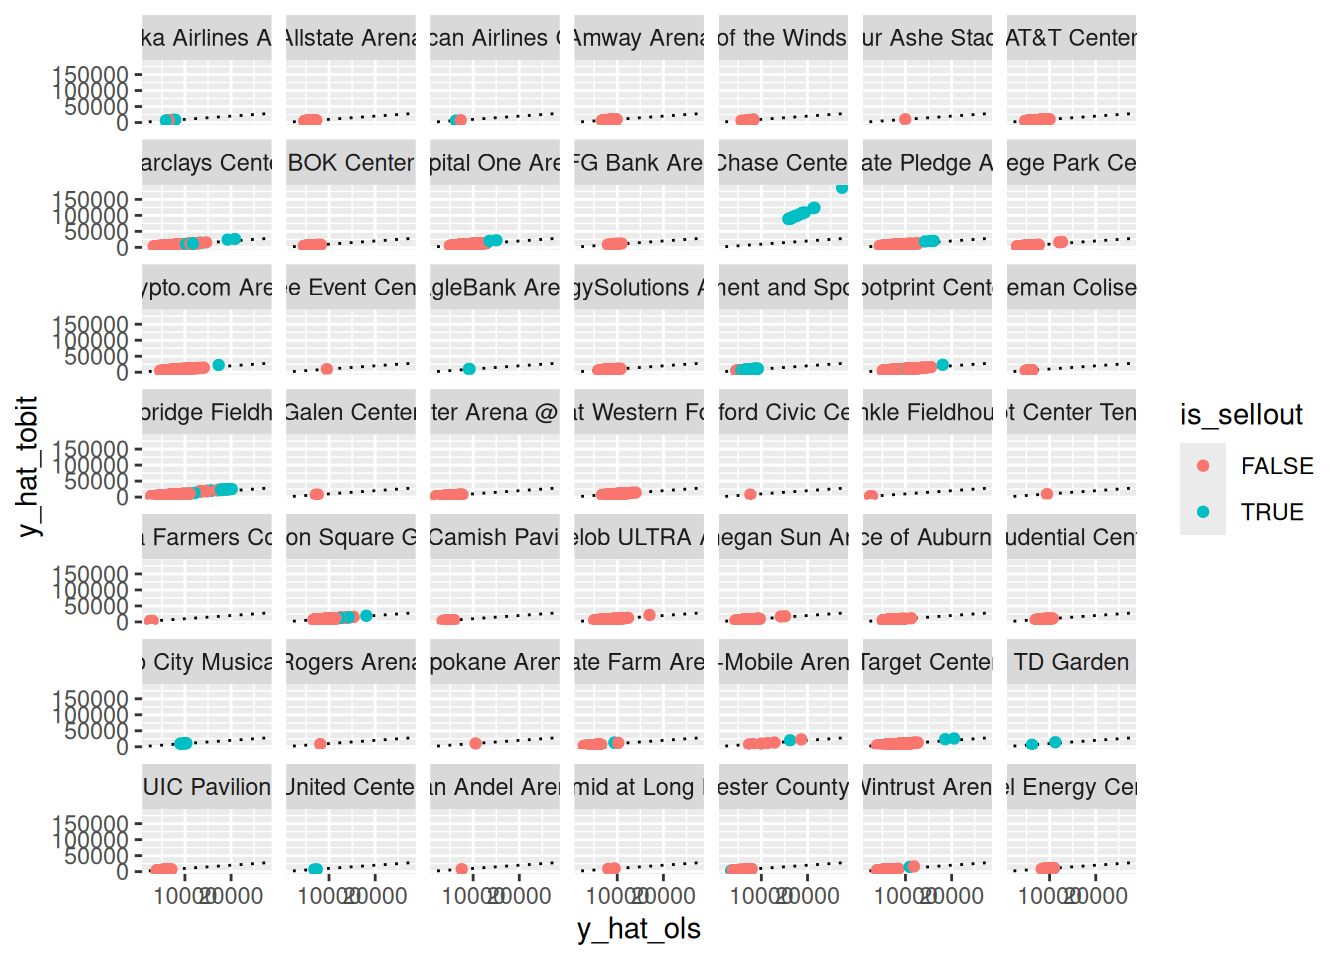

# A tibble: 1 × 1
  cor[,1]
    <dbl>
1   0.618

In [ ]:
wnba_df <- wnba_df |>
  mutate(
    y_hat_ols = exp(fitted(mod_ols)),
    y_hat_tobit = exp(fitted(mod_tobit))
  )

ggplot(data = wnba_df, aes(x = y_hat_ols, y = y_hat_tobit, color = is_sellout)) +
  geom_abline(slope = 1, linetype = 3) + 
  geom_point() +
  facet_wrap(vars(arena))

In [ ]:
library(broom)
tidy.vglm <- broom.helpers::tidy_vgam

### 4.1 Modeling attendance

#### 4.1.1 Baseline effects

<a href="#tbl-coefs" class="quarto-xref">Table 5</a> reports estimated coefficients in the Tobit model. Because each measure of fan engagement interacts with season, the reported coefficients for quality of play, outcome uncertainty, and loss aversion represent their estimated effects for the reference level: a home game for the Atlanta Dream taking place on a Sunday in August 1997, in which neither Clark nor Wilson is playing. The interaction terms, discussed in <a href="#sec-annual" class="quarto-xref">Section 4.1.2</a>, capture how these relationships evolve over time.

In [ ]:
sanitize_terms <- function(x) {
  x |>
    str_replace_all("factor\\(name_current\\)", "Team: ") |>
    str_replace_all("as.character\\(wday\\(game_date\\, label = TRUE\\, abbr = FALSE\\)\\)", "Day: ") |>
    str_replace_all("as.character\\(month\\(game_date\\, label = TRUE\\, abbr = FALSE\\)\\)", "Month: ") |>
    str_replace_all("is_cc", "Player: Caitlin Clark") |>
    str_replace_all("is_aw", "Player: A'ja Wilson")
}

label_coefs <- function(x) {
  case_when(
    x == "(Intercept):1" ~ "$\\hat{\\beta}_0$",
    x == "(Intercept):2" ~ "$\\hat{\\sigma}$",
    str_detect(x, "z1") ~ "$\\hat{\\beta}_1$",
    str_detect(x, "z2") ~ "$\\hat{\\beta}_2$",
    str_detect(x, "z3") ~ "$\\hat{\\beta}_3$",
    x == "is_cc" ~ "$\\hat{\\beta}_{10}$",
    x == "is_aw" ~ "$\\hat{\\beta}_{11}$",
    x == "median_income" ~ "$\\hat{\\beta}_8$",
    x == "metro_pop" ~ "$\\hat{\\beta}_9$",
    TRUE ~ "",
  )
}

In [ ]:
mod_attend_coefs <- mod_attend |>
  tidy(conf.int = TRUE) |>
#  map(broom::tidy, conf.int = TRUE) |>
  bind_rows(.id = "model") 

min_cc <- mod_attend_coefs |>
  filter(term == "is_cc") |>
  select(estimate) |>
  min()

beta_quality <- mod_attend_coefs |>
  filter(term == "I(z1_quality_of_play)") |>
  pull(estimate)

mod_attend_coefs |>
  filter_out(str_detect(term, "factor|name_current|character")) |>
  mutate(
    coef = label_coefs(original_term),
    term = sanitize_terms(original_term)
  ) |>
  select(coef, term, estimate, std.error, statistic, p.value, conf.low, conf.high) |>
  arrange(term) |>
  janitor::clean_names(case = "title") |>
  my_gt() |>
  fmt_markdown(columns = Coef) |>
  fmt_number(decimals = 3)

In the reference season, the evidence for loss aversion ($\hat{\beta}_3$) and uncertainty of outcome ($\hat{\beta}_2$) is weak, with those coefficients being of little significance, either practically or statistically. The coefficient for quality of play ($\hat{\beta}_1$, which *is* statistically significant) suggests that in 1997, a 1 standard deviation increase in the quality of play (as measured by the product of the Elo ratings) is associated with a modest 2.15% increase in the expected latent attendance, after controlling for our other factors. The support for quality of play (relative to uncertainty of outcome and loss aversion) as a driver of attendance is a key finding.

Games featuring Caitlin Clark were associated with substantially higher attendance ($\hat{\beta}_{10}$), while A’ja Wilson’s presence was associated with a smaller but still nontrivial increase in attendance ($\hat{\beta}_{11}$). The expected latent attendance more than doubles (i.e., is multiplied by $\exp(\text{0.846})$ = 2.33) when Clark plays in the game, and this is *after* controlling for the Indiana Fever team effect, the levels of fan engagement, and the season effects! The corresponding change in attendance for A’ja Wilson—by most accounts a better player than Clark—is multiplication by just 1.05.

Among the control variables, median income ($\hat{\beta}_8$) and metro area population ($\hat{\beta}_9$) had small negative effects after controlling for other variables.

<a href="#fig-attend-coefs" class="quarto-xref">Figure 7</a> presents the results of <a href="#tbl-coefs" class="quarto-xref">Table 5</a> and some additional coefficients graphically. Confidence intervals for the coefficient associated with the Golden State Valkyries (who have sold out all 22 of their home games) is omitted because it was so large that it renders all of the other effects indistinguishable. The New York Liberty have the largest team effect ($\hat{\beta}_7$), and all teams are positive relative to the Dream. Saturday games have the highest attendance ($\hat{\beta}_6$), as do games later in the season ($\hat{\beta}_5$).

In [ ]:
plot_attend_coefs <- mod_attend_coefs |>
  filter_out(str_detect(term, "(arena)|:|Intercept|median|metro|season|Golden")) |>
  mutate(
    hilite = str_detect(term, "is_cc|2025|quality"),
    term = sanitize_terms(term)
  ) |>
  ggplot(aes(x = exp(estimate), y = term, color = hilite)) +
  geom_vline(xintercept = 1, linetype = 3) +
  geom_point() +
  geom_errorbar(aes(xmin = exp(conf.low), xmax = exp(conf.high)), width = 0.1) +
  scale_x_continuous(latex2exp::TeX(r"(Exponentiated Fitted Coefficient ($\exp{(\hat{\beta}_i)}$))")) +
  scale_y_discrete("Term or factor level") +
  scale_color_discrete(guide = "none")
plot_attend_coefs

In [ ]:
glance.vglm <- function(x, ...) {
  tibble::tibble(
    nobs        = VGAM::nobs(x),
    df.residual = VGAM::df.residual(x),
    logLik      = as.numeric(stats::logLik(x)),
    AIC         = AIC(x),
    BIC         = BIC(x),
#    deviance    = if (length(x@criterion$deviance) > 0) x@criterion$deviance else NA_real_
  )
}

<a href="#tbl-glance" class="quarto-xref">Table 8</a> characterizes the model’s fit and <a href="#tbl-anova-tobit" class="quarto-xref">Table 9</a> shows the ANOVA table. The Tobit coefficient of -1.18 approximates the standard deviation of the latent attendance (on the log scale) when exponentiated (i.e., 0.307).

#### 4.1.2 Annual effects

<a href="#tbl-lrt" class="quarto-xref">Table 6</a> shows a likelihood ratio test between our model and a reduced model that does not include the interaction terms. The interactions introduce 78 additional terms corresponding to season specific slopes to our model. The likelihood ratio test rejects the null hypothesis that all season-specific changes in slope are equal to zero, indicating that the effects of our fan engagement measures differ significantly across seasons.

The ANOVA table shown in <a href="#tbl-anova-tobit" class="quarto-xref">Table 9</a> further support the inclusion of all three sets of interaction terms.

In [ ]:
anova(mod_tobit_basic, mod_tobit, type = "I") |>
  my_gt() |>
  fmt_number(columns = `Pr(>Chi)`, decimals = 3)

<a href="#fig-season-coefs" class="quarto-xref">Figure 8</a> isolates the change in intercept associated with each WNBA season (the various values of the vector $\hat{\beta}_4$). These reveal that even after controlling for our other variables—including the Caitlin Clark effect—expected attendance has exceeded its 1997 baseline in the most recent seasons. Thus, even after controlling for the influence of Clark and Wilson, league expected attendance has fully recovered from the COVID-19 pandemic and the malaise of the early 2000s and 2010s. This is a second key finding.

In [ ]:
plot_attend_seasons <- mod_attend_coefs |>
  filter(str_detect(term, "season_id")) |>
  filter_out(str_detect(term, ":")) |>
  mutate(season_id = parse_number(str_sub(term, -4))) |>
  bind_rows(tibble(season_id = 1997, estimate = 0)) |>
  ggplot(aes(x = season_id, y = exp(estimate))) +
  geom_point() +
  geom_hline(yintercept = 1, linetype = 3) +
  geom_line() +
  geom_errorbar(aes(ymin = exp(conf.low), ymax = exp(conf.high), width = 0.2)) +
  scale_x_continuous("Season") +
  scale_y_continuous("Exponentiated Fitted Season Fixed Effect") +
  theme_minimal(base_size = 10)
plot_attend_seasons

<a href="#fig-season-slopes" class="quarto-xref">Figure 9</a> shows the exponentiated season-by-season combined slopes for our three measures of fan engagement. The initial values ($\hat{\beta}_1, \hat{\beta}_2, \hat{\beta}_3$, corresponding to 1997), match those in <a href="#tbl-coefs" class="quarto-xref">Table 5</a>, and the subsequent interaction terms ($\hat{\beta}_{12}, \hat{\beta}_{13}, \hat{\beta}_{14}$) modify the relationships between attendance and fan engagement. In <a href="#fig-season-slopes" class="quarto-xref">Figure 9</a>, we can see that there is little to no association with attendance from the uncertainty of the outcome.[1] The slope associated with loss aversion ($\hat{\beta}_3 + \hat{\beta}_{14}$) is always positive and generally increasing, suggesting that the attendance response to home win probability has strengthened over the league’s history. While Agha and Berri ([2023](#ref-AghaBerri2023)) did not find a statistically significant relationship between team strength and demand between 2004 and 2017, our analysis finds that estimated home win probability is a statistically significant predictor of attendance. We use game-level expected probabilities and incorporate a more recent period of league growth, finding that estimated home win probability is a statistically significant predictor of attendance and that its effect has strengthened over time. This suggests that fan behavior in the WNBA may be becoming more similar to the behavior observed in Major League Baseball by Coates et al. ([2014](#ref-CoatesHumphreysZhou2014)).

Similarly, the slope associated with quality of play ($\hat{\beta}_1 + \hat{\beta}_{12}$) is always positive and generally increasing, following a steep fall after the league’s first season. One possible explanation for the anomalously large fitted slope in 1997 is that a few very good and/or very bad teams stood out in the first year in the league. Another plausible explanation is that since all teams started with an initial Elo rating of 1500, it took a while for the relationship between attendance and team strength to settle down.

In the case of quality of play and loss aversion, the exponentiated fitted coefficient value of approximately 0.1 in recent years means that a one standard deviation increase in these measures is associated with an increase in attendance that is about 10% higher than it would have been in the league’s early years. This is another key finding.

[1] See the previous note about possible misspecification of the uncertainty of outcome variable.

In [ ]:
combine_slopes <- function(data) {
  slopes <- data |>
    filter(str_detect(term, "z")) |>
    mutate(
      type = ifelse(str_detect(term, "\\)$"), "main", "interaction"),
      season_id = parse_number(str_sub(term, -4)),
      variable = str_extract(term, "z[0-9][a-z,_]+")
    )
  
  main_slopes <- slopes |>
    filter(type == "main") |>
    mutate(season_id = 1997) |>
    select(season_id, variable, estimate, conf.low, conf.high)
  
  changes_in_slopes <- slopes |>
    filter(type == "interaction") |>
    select(season_id, variable, estimate, conf.low, conf.high) |>
    bind_rows(main_slopes)
  
  changes_in_slopes |>
    left_join(
      main_slopes |> select(variable, main_slope = estimate), 
      by = join_by(variable)
    ) |>
    mutate(combined_slope = main_slope + estimate)
}

In [ ]:
plot_attend_slopes <- mod_attend_coefs |>
  combine_slopes() |>
  ggplot(aes(x = season_id, y = exp(combined_slope), color = variable)) +
  geom_hline(yintercept = 1, linetype = 3) +
  geom_line() +
#  geom_errorbar(aes(ymin = conf.low, ymax = conf.high, width = 0.2)) +
  geom_smooth(se = 0) +
  scale_x_continuous("Season") +
  scale_y_continuous("Exponentiated Fitted Combined Slope Coefficient") +
  theme_minimal(base_size = 10)
plot_attend_slopes

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

### 4.2 Modeling percentage of arena capacity

In [ ]:
# Arena capacity
mod_tobit_pct <- vglm(
  formula = update(mod_ols, pct_capacity_safe ~ .),
  family = tobit(Upper = 1, Lower = 0, imethod = 2), 
  data = wnba_df,
  na.action = "na.exclude"
)

In [ ]:
library(lmtest)

Loading required package: zoo


Attaching package: 'zoo'

The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Attaching package: 'lmtest'

The following object is masked from 'package:VGAM':

    lrtest

#### 4.2.1 Main effects

<a href="#tbl-coefs2" class="quarto-xref">Table 7</a> reports the coefficients from the percentage of estimated arena capacity model, while <a href="#fig-pct-coefs" class="quarto-xref">Figure 10</a> graphically illustrates the relatively magnitude of the coefficients. The results largely mirror those of the Tobit model (compare to <a href="#tbl-coefs" class="quarto-xref">Table 5</a>).

In [ ]:
mod_pct_coefs <- mod_pct |>
  lmtest::coeftest(vcov_pct) |>
  broom::tidy(conf.int = TRUE)

mod_pct_coefs |>
  filter_out(str_detect(term, "factor|name|character")) |>  
  mutate(
    coef = ifelse(term == "(Intercept)", "$\\hat{\\beta}_0$", label_coefs(term)),
    term = sanitize_terms(term)
  ) |>
  select(coef, everything()) |>
  arrange(term) |>
  janitor::clean_names(case = "title") |>
  my_gt() |>
  fmt_markdown(Coef) |>
  fmt_number(decimals = 3)

In this model, the effect associated with Caitlin Clark’s appearance ($\hat{\beta}_{10}$) is even more dramatic. After controlling for our other factors, Clark’s presence is associated with a 6.8-fold increase in the ratio of the expected percentage of the arena filled relative to the percentage that is empty. In other words, for an arena that would otherwise be expected to be half-full, Clark’s marginal effect corresponds to a jump in the expected percentage of arena capacity to nearly 0.98%. Clark has played all but one of her games in arena’s that were more than 85% full (recall that the league average is about 50%).

In [ ]:
plot_attend_coefs +
  mod_pct_coefs |>
  filter_out(str_detect(term, "(arena)|:|Intercept|median|Golden|season")) |>
  mutate(
    hilite = str_detect(term, "is_cc|2025|quality"),
    term = sanitize_terms(term)
  )

<a href="#tbl-glance2" class="quarto-xref">Table 10</a> and <a href="#tbl-anova2" class="quarto-xref">Table 11</a> show model fit metrics and analysis of variance for the percentage of estimated arena capacity models, respectively.

#### 4.2.2 Annual effects

<a href="#fig-season-coefs2" class="quarto-xref">Figure 11</a> displays the estimated effects of our fan engagement measures on attendance relative to the 1997 reference season. Similar to the attendance trends shown in <a href="#fig-season-coefs" class="quarto-xref">Figure 8</a>, these effects generally remained below their 1997 levels for much of the league’s history and only returned to comparable levels recently. In the most recent years of measurement, however, we see the league exceeding its previous highs.

In [ ]:
plot_attend_seasons +
  mod_pct_coefs |>
  filter(str_detect(term, "season_id")) |>
  filter_out(str_detect(term, ":")) |>
  mutate(season_id = parse_number(str_sub(term, -4))) |>
  bind_rows(tibble(season_id = 1997, estimate = 0))

<a href="#fig-season-slopes2" class="quarto-xref">Figure 12</a> shows that the changes in slopes associated with our measures of fan engagement follow similar patterns to those shown in <a href="#fig-season-slopes" class="quarto-xref">Figure 9</a>.

In [ ]:
plot_attend_slopes +
  mod_pct_coefs |>
  combine_slopes()

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

## 5 Conclusion

### 5.1 Key results

After considering attendance across the entire history of the WNBA, we arrive at several conclusions.

First, the effect of Caitlin Clark’s presence on attendance is substantial. As discussed above, Clark’s presence in a game more than doubles the expected attendance, even after controlling for other factors. Although interest in a single star player is not by itself evidence of sustained development, it is notable that earlier work did not find star players to be significant drivers of WNBA game attendance ([Agha and Berri 2023](#ref-AghaBerri2023)).

Second, as has been widely reported, attendance has reached new heights in recent years even after controlling for Clark’s presence and other game, team, and market characteristics. This means that the league’s recent success cannot be attributed only to the “Caitlin Clark effect” and instead indicates a broader increase in demand. The Golden State Valkyries filled all 18,064 seats in each one of their 22 home games in 2025, only one of which involved Clark.

Finally, we find evidence that the relationships between attendance and our measurements of both quality of play and loss aversion have strengthened over time. The effect of quality of play appears to be more robust than the effect of our measurements of either loss aversion or uncertainty of outcome.

These findings suggest that the WNBA is entering a more mature stage of development, in which fans increasingly attend games for the product on the court rather than primarily out of novelty or support for women’s sports.

### 5.2 Limitations and future work

We considered fitting a period-based model that would allow us to isolate specific periods across the league’s history and craft a more narrative explanation of fan engagement trends. We ultimately decided against this approach because defining periods by hand would require subjective decisions about the timing of structural breaks and would risk introducing researcher bias into the analysis.

There are reasonable objections to the way that we defined our measures of fan engagement. We sought definitions that were supported in the literature and could be compared directly, but other approaches could also be valid. In particular, our definition of the uncertainty of outcome is maximized when the two teams are equally strong, but one could argue that this should not be where the maximum occurs or that fans seek a range of uncertainty rather than a single point. Coates et al. ([2014](#ref-CoatesHumphreysZhou2014)) use a reference based definition of uncertainty and find that fans only respond to uncertainty when other conditions are met, incorporating a reference based definition could be useful in future research in the WNBA context.

There is no theoretical explanation for why the slopes in <a href="#fig-season-slopes2" class="quarto-xref">Figure 12</a> should converge to the same value.

With just two seasons in our data set, while Clark’s impact on attendance is undeniable, only time will tell if this impact is persistent.[1] It may very well be the case that as Clark’s novelty wears off, her effect on attendance wanes. A follow-up study could investigate this possibility.

Finally, while we chose to focus on live, in-person game attendance, fan engagement with games on television and streaming also provide important insight into league health and development. Future research might investigate what drives fans’ engagement with games from their own homes, where the lower cost of engagement might influence fan behavior.

## References

Agha, Nola, and David Berri. 2023. “Demand for Basketball: A Comparison of the WNBA and NBA.” *International Journal of Sport Finance* 18 (1): 35–44. <https://doi.org/10.32731/IJSF/181.022023.03>.

Coates, Dennis, Brad R. Humphreys, and Li Zhou. 2014. “Reference-Dependent Preferences, Loss Aversion, and Live Game Attendance.” *Economic Inquiry* 52 (3): 959–73. <https://doi.org/10.1111/ecin.12061>.

Davis, Michael C. 2008. “The Interaction Between Baseball Attendance and Winning Percentage: A VAR Analysis.” *International Journal of Sport Finance* 3 (1): 58–73. <https://doi.org/10.1177/155862350800300105>.

Davis, Michael C. 2009. “Analyzing the Relationship Between Team Success and MLB Attendance with GARCH Effects.” *Journal of Sports Economics* 10 (1): 44–58. <https://doi.org/10.1177/1527002508327387>.

Delia, Elizabeth B. 2020. “The Psychological Meaning of Team Among Fans of Women’s Sport.” *Journal of Sport Management* 34 (6): 579–90. <https://doi.org/10.1123/jsm.2019-0404>.

DeSchriver, Timothy D, and Paul E Jensen. 2002. “Determinants of Spectator Attendance at NCAA Division II Football Contests.” *Journal of Sport Management* 16 (4): 311–30. <https://doi.org/10.1123/jsm.16.4.311>.

Elo, A. E. 1978. *The Rating of Chessplayers, Past and Present*. New York: Arco Publishing.

Garcia, Christopher. 2020. “"Betting on Women": A Feminist Political Economic Critique of Ideological Sports Narratives Surrounding the WNBA.” *The Political Economy of Communication* 8 (1). <https://polecom.org/index.php/polecom/article/view/119>.

Gilani, Saiem, and Geoffery Hutchinson. 2021. “Wehoop: Access Women’s Basketball Play by Play Data.” In *CRAN: Contributed Packages*. The R Foundation. <https://doi.org/10.32614/cran.package.wehoop>.

Guest, Andrew M, and Anne Luijten. 2018. “Fan Culture and Motivation in the Context of Successful Women’s Professional Team Sports: A Mixed-Methods Case Study of Portland Thorns Fandom.” *Sport in Society* 21 (7): 1013–30. <https://doi.org/10.1080/17430437.2017.1346620>.

Hall, Stephen, Stefan Szymanski, and Andrew S Zimbalist. 2002. “Testing Causality Between Team Performance and Payroll: The Cases of Major League Baseball and English Soccer.” *Journal of Sports Economics* 3 (2): 149–68. <https://doi.org/10.1177/152700250200300204>.

Heinzen, Ethan. 2023. *Elo: Ranking Teams by Elo Rating and Comparable Methods*. <https://github.com/eheinzen/elo>.

Horowitz, Ira. 2007. “If You Play Well They Will Come-and Vice Versa: Bidirectional Causality in Major-League Baseball.” *Managerial and Decision Economics* 28 (2): 93–105. <https://doi.org/10.1002/mde.1308>.

Kim, Rhino, and Sue Ryung Chang. 2023. “Winning Back Attendance: Effects of Winning Performance, Online Search, and the MLB Rule Changes for More Dynamic Games.” *Asia Marketing Journal* 25 (3): 148–59. <https://doi.org/10.53728/2765-6500.1616>.

Lemke, Robert J, Matthew Leonard, and Kelebogile Tlhokwane. 2010. “Estimating Attendance at Major League Baseball Games for the 2007 Season.” *Journal of Sports Economics* 11 (3): 316–48. <https://doi.org/10.1177/1527002509337212>.

Leslie-Walker, Anika, and Claire Mulvenna. 2022. “The Football Association’s Women’s Super League and Female Soccer Fans: Fan Engagement and the Importance of Supporter Clubs.” *Soccer & Society* 23 (3): 314–27. <https://doi.org/10.1080/14660970.2022.2037218>.

MacKinnon, James G, and Halbert White. 1985. “Some Heteroskedasticity-Consistent Covariance Matrix Estimators with Improved Finite Sample Properties.” *Journal of Econometrics* 29 (3): 305–25. <https://doi.org/10.1016/0304-4076(85)90158-7>.

McDonald, John F, and Robert A Moffitt. 1980. “The Uses of Tobit Analysis.” *The Review of Economics and Statistics*, 318–21. <https://www.jstor.org/stable/1924766>.

Neale, Walter C. 1964. “The Peculiar Economics of Professional Sports.” *The Quarterly Journal of Economics* 78 (1): 1–14. <https://doi.org/10.2307/1880543>.

Noll, Roger G. 1974. *Attendance and Price Setting*. Edited by Roger G Noll. Washington, D.C.: Brookings Institution.

Papke, Leslie E, and Jeffrey M Wooldridge. 1996. “Econometric Methods for Fractional Response Variables with an Application to 401 (k) Plan Participation Rates.” *Journal of Applied Econometrics* 11 (6): 619–32. [https://doi.org/10.1002/(SICI)1099-1255(199611)11:6\<619::AID-JAE418\>3.0.CO;2-1](https://doi.org/10.1002/(SICI)1099-1255(199611)11:6<619::AID-JAE418>3.0.CO;2-1).

Paul, Rodney, Andrew Weinbach, and Nick Riccardi. 2019. “Attendance in the Canadian Hockey League: The Impact of Winning, Fighting, Uncertainty of Outcome, and Weather on Junior Hockey Attendance.” *International Journal of Financial Studies* 7 (1): 12. <https://doi.org/10.3390/ijfs7010012>.

Perline, Martin M., Jeffrey S. Noble, and G. Clayton Stoldt. 2018. “Competitive Balance in NCAA ‘Power Conferences:’ The Case of Men’s and Women’s Basketball.” *The Sport Journal* 21.

Rottenberg, Simon. 1956. “The Baseball Players’ Labor Market.” *Journal of Political Economy* 64 (3): 242–58. <https://doi.org/10.1086/257790>.

Tobin, James. 1958. “Estimation of Relationships for Limited Dependent Variables.” *Econometrica*, 24–36. <https://doi.org/10.2307/1907382>.

Walker, Kyle, and Matt Herman. 2026. *Tidycensus: Load US Census Boundary and Attribute Data as Tidyverse and Sf-Ready Data Frames*. <https://walker-data.com/tidycensus/>.

Wasserstein, Ronald L, and Nicole A Lazar. 2016. “The ASA Statement on p-Values: Context, Process, and Purpose.” *The American Statistician* 70 (2): 129–33. <https://doi.org/10.1080/00031305.2016.1154108>.

Wasserstein, Ronald L, Allen L Schirm, and Nicole A Lazar. 2019. “Moving to a World Beyond ‘p\< 0.05’.” *The American Statistician* 73 (sup1): 1–19. <https://doi.org/10.1080/00031305.2019.1583913>.

Wiseman, Frederick, and Sangit Chatterjee. 2003. “Team Payroll and Team Performance in Major League Baseball: 1985–2002.” *Economics Bulletin* 1 (2): 1–10. <https://accessecon.com/pubs/eb/2003/volume1/eb-03a10003a.pdf>.

WNBA. 2024. “WNBA Delivers Record‑setting 2024 Season.” <https://www.wnba.com/news/wnba-delivers-record-setting-2024-season>.

Woltring, Mitchell T. 2018. “Attendance Still Matters in MLB: The Relationship with Winning Percentage.” *The Sport Journal*, November 22. <https://thesportjournal.org/article/attendance-still-matters-in-mlb-the-relationship-with-winning-percentage/>.

Yee, Thomas. 2025. *VGAM: Vector Generalized Linear and Additive Models*. <https://www.stat.auckland.ac.nz/~yee/VGAM/>.

Zeileis, Achim, and Thomas Lumley. 2026. *Sandwich: Robust Covariance Matrix Estimators*. <https://sandwich.R-Forge.R-project.org/>.

Zimmerman, Kurtis. 2026. *Game-by-Game Attendance*. Across the Timeline. <https://www.acrossthetimeline.com/wnba/attendance.html>.

## 6 Appendix

### 6.1 Distribution of fan engagement

[1] The excitement that Clark has brought to the WNBA may be reminiscent of the infusion of interest in the NBA that occurred in the early- to mid-1980s with the arrival of Magic Johnson, Larry Bird, and Michael Jordan.

In [ ]:
wnba_gl |>
  select(matches("^z")) |>
  pivot_longer(cols = everything(), values_to = "value", names_to = "fan_engagement") |>
  ggplot(aes(x = value)) +
  geom_histogram() +
  facet_wrap(vars(fan_engagement), ncol = 1) + 
  theme_minimal(base_size = 10) +
  scale_x_continuous("Standard deviations above the mean")

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.

### 6.2 Relationship between attendance and fan engagement

In [ ]:
plot_attend +
  aes(x = z1_quality_of_play) +
  scale_x_continuous("Normalized Quality of Play") +
  scale_y_log10("Attendance")

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.

In [ ]:
plot_attend +
  aes(x = z2_uncertain_outcome) +
  scale_x_continuous("Normalized Uncertainty of Outcome") + 
  scale_y_log10("Attendance")

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.

In [ ]:
plot_capacity +
  aes(x = z1_quality_of_play) + 
  scale_x_continuous("Normalized Quality of Play")

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.

In [ ]:
plot_capacity +
  aes(x = z2_uncertain_outcome) +
  scale_x_continuous("Normalized Uncertainty of Outcome")

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.

### 6.3 Model fitting metrics for attendance model

In [ ]:
mod_attend |>
  broom::glance() |>
  bind_rows(.id = "model") |>
  knitr::kable(digits = 3)

In [ ]:
mod_attend |>
  anova() |> as_tibble(rownames = "term") |>
  janitor::clean_names(case = "title") |>
  my_gt() |>
  fmt_number(columns = c(`X2 log Lik Diff`, `Log Lik`, `Pr Chi`), decimals = 3)

### 6.4 Model fitting metrics for percentage of arena capacity model

In [ ]:
mod_pct |>
  broom::glance() |>
  knitr::kable()

In [ ]:
mod_pct |>
  anova() |>
  broom::tidy() |>
  filter_out(str_detect(term, "NULL")) |>
  janitor::clean_names(case = "title") |>
  my_gt() |>
  fmt_number(columns = c(`Deviance`, `Residual Deviance`, `P Value`), decimals = 3)